# Análisis Estadístico de Montos de Siniestralidad por Línea de Negocio
### Comparación de grupos mediante prueba t y ANOVA de un factor — Caso Quan (InsurTech)

**Autor:** Santiago Moreno
**Programa:** Especialización en Analítica de Datos y Ciencia de Datos
**Contexto organizacional:** Quan es una compañía InsurTech colombiana que ofrece productos de seguros y
asistencia en cuatro líneas de negocio: **movilidad, mascotas, salud y hogar**. Este análisis busca aportar
insumos estadísticos para decisiones de reservas técnicas, priorización operativa y tarificación de riesgo
entre líneas.

**Nota metodológica sobre la fuente de datos:** por razones de confidencialidad de la información de
clientes y para garantizar la reproducibilidad del análisis por terceros, **no se utilizan registros reales
de producción de Quan**. En su lugar, se construyó un conjunto de datos **simulado**, con la misma
estructura de líneas de negocio de Quan, calibrado a partir de benchmarks públicos reales de severidad de
siniestros por ramo (fuentes citadas en el informe académico: Insurance Information Institute, Triple-I,
Embrace Pet Insurance, y el dataset de costos médicos individuales usado en Lantz, *Machine Learning with
R*). Es decir: la **estructura organizacional y los órdenes de magnitud son reales y verificables**; los
registros individuales son sintéticos.

**Objetivo:** determinar si existen diferencias estadísticamente significativas en el monto de
siniestralidad (`monto_siniestro`) entre (a) las cuatro líneas de negocio de Quan y (b) los dos tipos de
reclamo dentro de la línea de movilidad (daños propios vs. responsabilidad civil), evaluando en cada caso el
supuesto de normalidad para decidir entre una prueba paramétrica o su alternativa no paramétrica.


In [1]:
# Librerías para manipulación de datos, visualización y pruebas estadísticas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 2)


## 1. Carga y preparación del conjunto de datos

In [2]:
# Cargar el dataset simulado (estructura de líneas de negocio de Quan, calibrado a benchmarks reales)
from pathlib import Path

ruta_datos = Path.cwd().parent / "data" / "siniestros_quan_simulado.csv"
df = pd.read_csv(ruta_datos)
df.head()


,linea_negocio,tipo_reclamo,monto_siniestro,antiguedad_poliza_meses,mes_siniestro
0,hogar,patrimonial,5686.59,27.8,8
1,mascotas,veterinario,621.56,43.4,8
2,salud,medico,10667.38,10.6,4
3,movilidad,responsabilidad_civil,10242.38,31.8,5
4,salud,medico,2784.30,14.2,3


In [3]:
print(f"Dimensiones: {df.shape[0]} registros, {df.shape[1]} variables\n")
df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum())


Dimensiones: 2000 registros, 5 variables

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   linea_negocio            2000 non-null   str    
 1   tipo_reclamo             2000 non-null   str    
 2   monto_siniestro          2000 non-null   float64
 3   antiguedad_poliza_meses  2000 non-null   float64
 4   mes_siniestro            2000 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 78.3 KB

Valores nulos por columna:
linea_negocio              0
tipo_reclamo               0
monto_siniestro            0
antiguedad_poliza_meses    0
mes_siniestro              0
dtype: int64


In [4]:
# Distribución de registros por línea de negocio y tipo de reclamo
df.groupby(["linea_negocio", "tipo_reclamo"])["monto_siniestro"].describe().round(2)


count      mean       std      min  \
linea_negocio tipo_reclamo                                                
hogar         patrimonial            500.0  15308.74  20465.79   885.89   
mascotas      veterinario            500.0    432.80    483.55    27.51   
movilidad     danos_propios          250.0   6371.18   6645.36   269.22   
              responsabilidad_civil  250.0   4448.20   4928.57   191.87   
salud         medico                 500.0  13836.88  11856.09  1056.83   

                                         25%       50%       75%        max  
linea_negocio tipo_reclamo                                                   
hogar         patrimonial            5161.76   9537.63  17304.56  254550.26  
mascotas      veterinario             158.62    294.31    504.44    4312.26  
movilidad     danos_propios          2299.03   4199.85   7850.12   46650.46  
              responsabilidad_civil  1599.43   3216.85   5594.72   49067.79  
salud         medico                 5922.57  10102.74  18079.52  106060.54

## 2. Análisis exploratorio de datos (EDA)

Se explora la distribución general de `monto_siniestro` y su comportamiento frente a las variables
categóricas de interés: `linea_negocio` y, dentro de movilidad, `tipo_reclamo`.

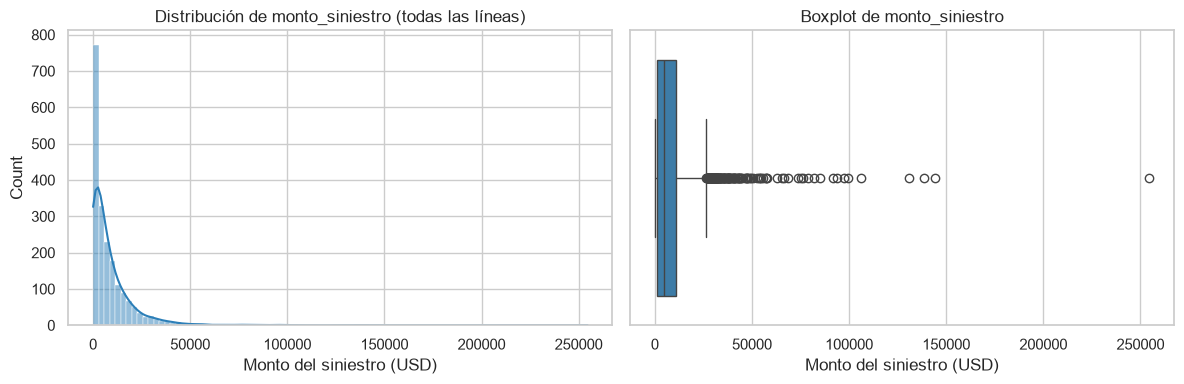

Asimetría (skewness): 6.053
Curtosis: 71.155


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["monto_siniestro"], kde=True, ax=ax[0], color="#2c7fb8")
ax[0].set_title("Distribución de monto_siniestro (todas las líneas)")
ax[0].set_xlabel("Monto del siniestro (USD)")
sns.boxplot(x=df["monto_siniestro"], ax=ax[1], color="#2c7fb8")
ax[1].set_title("Boxplot de monto_siniestro")
ax[1].set_xlabel("Monto del siniestro (USD)")
plt.tight_layout()
plt.show()

print(f"Asimetría (skewness): {stats.skew(df['monto_siniestro']):.3f}")
print(f"Curtosis: {stats.kurtosis(df['monto_siniestro']):.3f}")


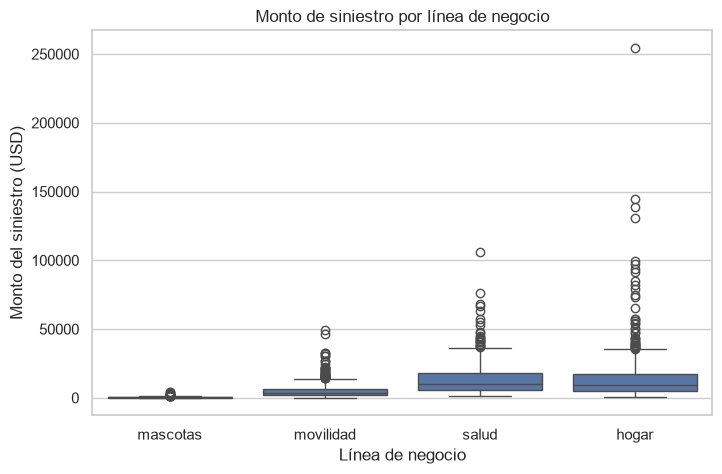

,count,mean,median,std
linea_negocio,,,,
mascotas,500,432.80,294.31,483.55
movilidad,500,5409.69,3669.54,5923.13
salud,500,13836.88,10102.74,11856.09
hogar,500,15308.74,9537.63,20465.79


In [6]:
orden_lineas = ["mascotas", "movilidad", "salud", "hogar"]
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="linea_negocio", y="monto_siniestro", order=orden_lineas)
plt.title("Monto de siniestro por línea de negocio")
plt.xlabel("Línea de negocio")
plt.ylabel("Monto del siniestro (USD)")
plt.show()

df.groupby("linea_negocio")["monto_siniestro"].agg(["count", "mean", "median", "std"]).loc[orden_lineas].round(2)


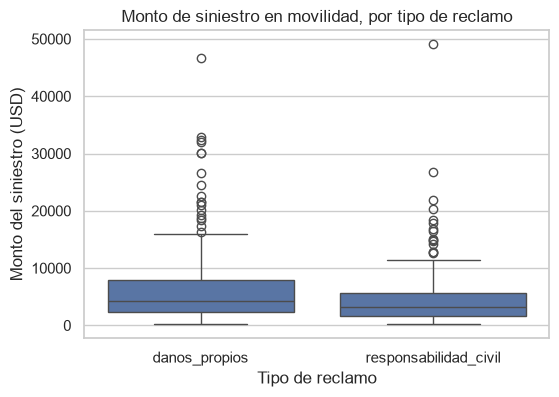

,count,mean,median,std
tipo_reclamo,,,,
danos_propios,250,6371.18,4199.85,6645.36
responsabilidad_civil,250,4448.20,3216.85,4928.57


In [7]:
df_movilidad = df[df["linea_negocio"] == "movilidad"].copy()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_movilidad, x="tipo_reclamo", y="monto_siniestro",
            order=["danos_propios", "responsabilidad_civil"])
plt.title("Monto de siniestro en movilidad, por tipo de reclamo")
plt.xlabel("Tipo de reclamo")
plt.ylabel("Monto del siniestro (USD)")
plt.show()

df_movilidad.groupby("tipo_reclamo")["monto_siniestro"].agg(["count", "mean", "median", "std"]).round(2)


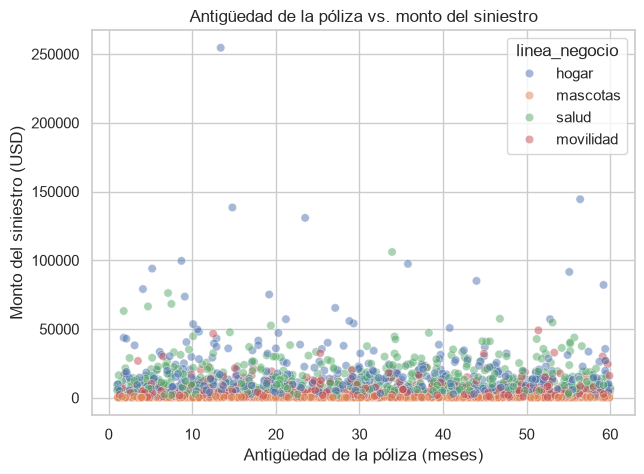

Correlación de Pearson: r=-0.023, p-valor=0.3140
Correlación de Spearman: rho=-0.017, p-valor=0.4402


In [8]:
# Dispersión: ¿la antigüedad de la póliza se relaciona con el monto del siniestro?
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="antiguedad_poliza_meses", y="monto_siniestro", hue="linea_negocio", alpha=0.5)
plt.title("Antigüedad de la póliza vs. monto del siniestro")
plt.xlabel("Antigüedad de la póliza (meses)")
plt.ylabel("Monto del siniestro (USD)")
plt.show()

corr_pearson, p_pearson = stats.pearsonr(df["antiguedad_poliza_meses"], df["monto_siniestro"])
corr_spearman, p_spearman = stats.spearmanr(df["antiguedad_poliza_meses"], df["monto_siniestro"])
print(f"Correlación de Pearson: r={corr_pearson:.3f}, p-valor={p_pearson:.4f}")
print(f"Correlación de Spearman: rho={corr_spearman:.3f}, p-valor={p_spearman:.4f}")


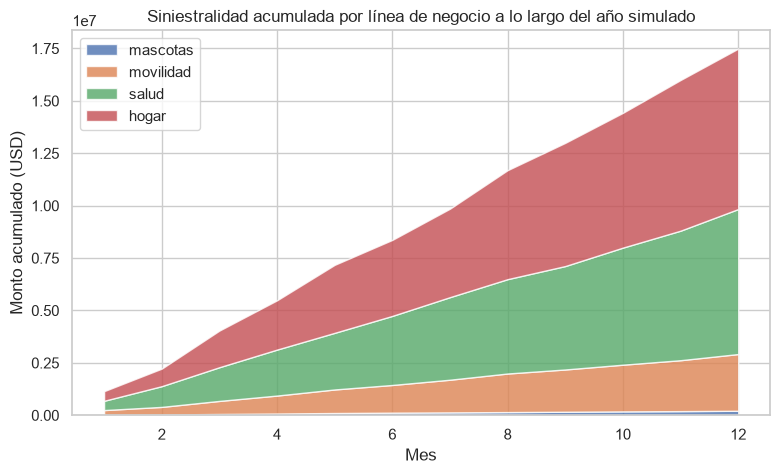

In [9]:
# Gráfico de área: siniestralidad acumulada mensual por línea de negocio
pivote_mensual = (
    df.groupby(["mes_siniestro", "linea_negocio"])["monto_siniestro"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=orden_lineas)
    .sort_index()
)
pivote_acumulado = pivote_mensual.cumsum()

plt.figure(figsize=(9, 5))
plt.stackplot(pivote_acumulado.index, pivote_acumulado.T, labels=orden_lineas, alpha=0.8)
plt.title("Siniestralidad acumulada por línea de negocio a lo largo del año simulado")
plt.xlabel("Mes")
plt.ylabel("Monto acumulado (USD)")
plt.legend(loc="upper left")
plt.show()


## 3. Verificación de supuestos estadísticos

Antes de aplicar una prueba t o un ANOVA (pruebas paramétricas), se verifica el cumplimiento de dos supuestos
clave: **normalidad** (Shapiro-Wilk) y **homogeneidad de varianzas** (Levene). Si no se cumplen, se prioriza
la alternativa no paramétrica correspondiente (U de Mann-Whitney en lugar de prueba t; Kruskal-Wallis en
lugar de ANOVA).

In [10]:
for linea in orden_lineas:
    datos = df.loc[df["linea_negocio"] == linea, "monto_siniestro"]
    stat, p = stats.shapiro(datos)
    print(f"Shapiro-Wilk ({linea}, n={len(datos)}): W={stat:.4f}, p-valor={p:.3e}")


Shapiro-Wilk (mascotas, n=500): W=0.6526, p-valor=1.255e-30
Shapiro-Wilk (movilidad, n=500): W=0.6984, p-valor=5.948e-29
Shapiro-Wilk (salud, n=500): W=0.7848, p-valor=3.759e-25
Shapiro-Wilk (hogar, n=500): W=0.5399, p-valor=4.125e-34


In [11]:
grupos_linea = [df.loc[df["linea_negocio"] == l, "monto_siniestro"] for l in orden_lineas]
levene_stat, levene_p = stats.levene(*grupos_linea)
print(f"Levene (línea de negocio): estadístico={levene_stat:.4f}, p-valor={levene_p:.3e}")

grupos_tipo_reclamo = [
    df_movilidad.loc[df_movilidad["tipo_reclamo"] == t, "monto_siniestro"]
    for t in ["danos_propios", "responsabilidad_civil"]
]
levene_stat_m, levene_p_m = stats.levene(*grupos_tipo_reclamo)
print(f"Levene (tipo de reclamo, movilidad): estadístico={levene_stat_m:.4f}, p-valor={levene_p_m:.4f}")


Levene (línea de negocio): estadístico=79.4577, p-valor=1.482e-48
Levene (tipo de reclamo, movilidad): estadístico=8.2840, p-valor=0.0042


## 4. Comparación entre dos grupos: tipo de reclamo en movilidad

Se compara el monto medio de siniestro entre reclamos de daños propios y de responsabilidad civil dentro de
la línea de movilidad.

In [12]:
danos_propios = df_movilidad.loc[df_movilidad["tipo_reclamo"] == "danos_propios", "monto_siniestro"]
resp_civil = df_movilidad.loc[df_movilidad["tipo_reclamo"] == "responsabilidad_civil", "monto_siniestro"]

# Prueba t de Welch (referencia paramétrica)
t_stat, t_p = stats.ttest_ind(danos_propios, resp_civil, equal_var=False)
print(f"Prueba t de Welch: t={t_stat:.4f}, p-valor={t_p:.4f}")

n1, n2 = len(danos_propios), len(resp_civil)
sd_combinada = np.sqrt(((n1 - 1) * danos_propios.std()**2 + (n2 - 1) * resp_civil.std()**2) / (n1 + n2 - 2))
cohen_d = (danos_propios.mean() - resp_civil.mean()) / sd_combinada
print(f"d de Cohen: {cohen_d:.3f}")

# U de Mann-Whitney (prueba no paramétrica)
u_stat, u_p = stats.mannwhitneyu(danos_propios, resp_civil, alternative="two-sided")
print(f"\nU de Mann-Whitney: U={u_stat:.1f}, p-valor={u_p:.4f}")

r_rb = 1 - (2 * u_stat) / (n1 * n2)
print(f"r biserial por rangos: {r_rb:.3f}")


Prueba t de Welch: t=3.6750, p-valor=0.0003
d de Cohen: 0.329

U de Mann-Whitney: U=37498.0, p-valor=0.0001
r biserial por rangos: -0.200


## 5. Comparación entre múltiples grupos: línea de negocio

Se compara el monto medio de siniestro entre las cuatro líneas de negocio de Quan.

In [13]:
modelo = ols("monto_siniestro ~ C(linea_negocio)", data=df).fit()
anova_tabla = sm.stats.anova_lm(modelo, typ=2)
print("ANOVA de un factor (monto_siniestro ~ linea_negocio):")
print(anova_tabla)

ss_between = anova_tabla["sum_sq"].iloc[0]
ss_total = anova_tabla["sum_sq"].sum()
eta_sq = ss_between / ss_total
print(f"\nEta cuadrado (ANOVA): {eta_sq:.4f}")

h_stat, h_p = stats.kruskal(*grupos_linea)
print(f"\nKruskal-Wallis: H={h_stat:.4f}, p-valor={h_p:.3e}")

n_total = len(df)
k = df["linea_negocio"].nunique()
epsilon_sq = (h_stat - k + 1) / (n_total - k)
print(f"Epsilon cuadrado (Kruskal-Wallis): {epsilon_sq:.4f}")


ANOVA de un factor (monto_siniestro ~ linea_negocio):
                    sum_sq      df       F    PR(>F)
C(linea_negocio)  7.46e+10     3.0  167.28  9.94e-97
Residual          2.97e+11  1996.0     NaN       NaN

Eta cuadrado (ANOVA): 0.2009

Kruskal-Wallis: H=1281.6057, p-valor=1.442e-277
Epsilon cuadrado (Kruskal-Wallis): 0.6406


In [14]:
# Comparaciones post-hoc de referencia (Tukey HSD) entre pares de líneas de negocio
tukey = pairwise_tukeyhsd(df["monto_siniestro"], df["linea_negocio"])
print(tukey)


         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
  group1    group2    meandiff  p-adj     lower       upper    reject
---------------------------------------------------------------------
    hogar  mascotas -14875.9369    0.0 -16858.8166 -12893.0571   True
    hogar movilidad   -9899.048    0.0 -11881.9278  -7916.1683   True
    hogar     salud  -1471.8563 0.2247   -3454.736    511.0235  False
 mascotas movilidad   4976.8888    0.0   2994.0091   6959.7686   True
 mascotas     salud  13404.0806    0.0  11421.2008  15386.9603   True
movilidad     salud   8427.1918    0.0    6444.312  10410.0715   True
---------------------------------------------------------------------


## 6. Síntesis de resultados

*(Resumen técnico de los hallazgos numéricos; la interpretación en profundidad, la discusión y las
conclusiones orientadas al negocio se desarrollan en el informe académico.)*

- **Distribución de `monto_siniestro`**: fuertemente asimétrica (asimetría ≈ 6.05, curtosis ≈ 71.2), con no
  normalidad confirmada por Shapiro-Wilk en las cuatro líneas (p < 0.001 en todos los casos). Se prioriza,
  por tanto, la lectura de las pruebas no paramétricas.
- **Movilidad — tipo de reclamo**: tanto la prueba t de Welch (p = 0.0003, d de Cohen = 0.33) como la U de
  Mann-Whitney (p = 0.0001, r biserial = -0.20) coinciden en que existe una diferencia estadísticamente
  significativa, de magnitud pequeña-moderada, entre reclamos de daños propios y de responsabilidad civil.
- **Línea de negocio**: tanto el ANOVA (F = 167.3, p ≈ 9.9e-97, η² = 0.20) como el Kruskal-Wallis
  (H = 1281.6, p ≈ 1.4e-277, ε² = 0.64) coinciden en una diferencia **altamente significativa y de gran
  magnitud** entre líneas. El post-hoc de Tukey muestra que todas las líneas difieren entre sí, **excepto
  hogar vs. salud**, que no se diferencian significativamente en severidad promedio (p = 0.22). Esto tiene
  implicación directa para la asignación de reservas técnicas: mascotas y movilidad requieren órdenes de
  magnitud distintos de reserva por siniestro frente a salud y hogar.
- **Antigüedad de la póliza vs. monto del siniestro**: correlación de Spearman prácticamente nula y no
  significativa (rho = -0.017, p = 0.44). La antigüedad de la póliza no es, en este conjunto de datos, un
  predictor relevante de la severidad del siniestro.
